# qml-implementation

For AWS Ecosystems Project

## Startup cells

In [0]:
# Set environment variables for sagemaker_studio imports

import os
os.environ['DataZoneProjectId'] = 'YOUR-PROJECT-ID'
os.environ['DataZoneDomainId'] = 'YOUR-DOMAIN-ID'
os.environ['DataZoneEnvironmentId'] = 'YOUR-ENVIRONMENT-ID'
os.environ['DataZoneDomainRegion'] = 'us-east-1'

# create both a function and variable for metadata access
_resource_metadata = None

def _get_resource_metadata():
    global _resource_metadata
    if _resource_metadata is None:
        _resource_metadata = {
            "AdditionalMetadata": {
                "DataZoneProjectId": "YOUR-PROJECT-ID",
                "DataZoneDomainId": "YOUR-DOMAIN-ID",
                "DataZoneEnvironmentId": "YOUR-ENVIRONMENT-ID",
                "DataZoneDomainRegion": "us-east-1",
            }
        }
    return _resource_metadata
metadata = _get_resource_metadata()

In [0]:
"""
Logging Configuration

Purpose:
--------
This sets up the logging framework for code executed in the user namespace.
"""

from typing import Optional


def _set_logging(log_dir: str, log_file: str, log_name: Optional[str] = None):
    import os
    import logging
    from logging.handlers import RotatingFileHandler

    level = logging.INFO
    max_bytes = 5 * 1024 * 1024
    backup_count = 5

    # fallback to /tmp dir on access, helpful for local dev setup
    try:
        os.makedirs(log_dir, exist_ok=True)
    except Exception:
        log_dir = "/tmp/kernels/"

    os.makedirs(log_dir, exist_ok=True)
    log_path = os.path.join(log_dir, log_file)

    logger = logging.getLogger() if not log_name else logging.getLogger(log_name)
    logger.handlers = []
    logger.setLevel(level)

    formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")

    # Rotating file handler
    fh = RotatingFileHandler(filename=log_path, maxBytes=max_bytes, backupCount=backup_count, encoding="utf-8")
    fh.setFormatter(formatter)
    logger.addHandler(fh)

    logger.info(f"Logging initialized for {log_name}.")


_set_logging("/var/log/computeEnvironments/kernel/", "kernel.log")
_set_logging("/var/log/studio/data-notebook-kernel-server/", "metrics.log", "metrics")

In [0]:
import logging
from sagemaker_studio import ClientConfig, sqlutils, sparkutils, dataframeutils

logger = logging.getLogger(__name__)
logger.info("Initializing sparkutils")
spark = sparkutils.init()
logger.info("Finished initializing sparkutils")

In [0]:
def _reset_os_path():
    """
    Reset the process's working directory to handle mount timing issues.
    
    This function resolves a race condition where the Python process starts
    before the filesystem mount is complete, causing the process to reference
    old mount paths and inodes. By explicitly changing to the mounted directory
    (/home/sagemaker-user), we ensure the process uses the correct, up-to-date
    mount point.
    
    The function logs stat information (device ID and inode) before and after
    the directory change to verify that the working directory is properly
    updated to reference the new mount.
    
    Note:
        This is executed at module import time to ensure the fix is applied
        as early as possible in the kernel initialization process.
    """
    try:
        import os
        import logging

        logger = logging.getLogger(__name__)
        logger.info("---------Before------")
        logger.info("CWD: %s", os.getcwd())
        logger.info("stat('.'): %s %s", os.stat('.').st_dev, os.stat('.').st_ino)
        logger.info("stat('/home/sagemaker-user'): %s %s", os.stat('/home/sagemaker-user').st_dev, os.stat('/home/sagemaker-user').st_ino)

        os.chdir("/home/sagemaker-user")

        logger.info("---------After------")
        logger.info("CWD: %s", os.getcwd())
        logger.info("stat('.'): %s %s", os.stat('.').st_dev, os.stat('.').st_ino)
        logger.info("stat('/home/sagemaker-user'): %s %s", os.stat('/home/sagemaker-user').st_dev, os.stat('/home/sagemaker-user').st_ino)
    except Exception as e:
        logger.exception(f"Failed to reset working directory: {e}")

_reset_os_path()

## Notebook

In [0]:
import sys
import subprocess
result = subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "amazon-braket-sdk", "pennylane", "amazon-braket-pennylane-plugin",
     "scikit-learn", "matplotlib", "boto3"],
    capture_output=True, text=True
)
print(result.stdout[-3000:])
print(result.stderr[-3000:])
print("Return code:", result.returncode)

━━━ 20/22 [pennylane]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━ 20/22 [pennylane]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━ 20/22 [pennylane]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━ 20/22 [pennylane]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━ 20/22 [pennylane]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━ 20/22 [pennylane]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━ 20/22 [pennylane]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━ 20/22 [pennylane]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━ 20/22 [pennylane]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━ 20/22 [pennylane]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━ 20/22 [pennylane]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━ 20/22 [pennylane]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━ 20/22 [pennylane]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━ 20/22 [pennylane]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━ 20/22 [pennylane]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━ 20/22 [pennylane]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━ 20/2

In [0]:
import numpy as np
import matplotlib.pyplot as plt
import boto3, json, time
from datetime import datetime
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, classification_report)
import pennylane as qml
from pennylane import numpy as pnp
print("All imports successful")
print(f"PennyLane version: {qml.__version__}")

All imports successful
PennyLane version: 0.44.1


/smus_kernel_server/.venv/lib/python3.11/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


In [0]:
S3_BUCKET = 'YOUR-BUCKET-NAME'
REGION = 'us-east-1'
N_QUBITS = 4
N_LAYERS = 3
N_EPOCHS = 60
LEARNING_RATE = 0.01
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print(f'Config loaded. Bucket: {S3_BUCKET}')
print(f'Qubits: {N_QUBITS}, Layers: {N_LAYERS}, Epochs: {N_EPOCHS}')

Config loaded. Bucket: YOUR-BUCKET-NAME
Qubits: 4, Layers: 3, Epochs: 60


In [0]:
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
print(f'Dataset: {cancer.target_names[0]} vs {cancer.target_names[1]}')
print(f'Total samples: {X.shape[0]}, Features: {X.shape[1]}')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
pca = PCA(n_components=N_QUBITS, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
print(f'Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')
angle_scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_enc = angle_scaler.fit_transform(X_train_pca)
X_test_enc  = angle_scaler.transform(X_test_pca)
print(f'Training: {X_train_enc.shape[0]} — Test: {X_test_enc.shape[0]}')
print('Data preparation complete')

Dataset: malignant vs benign
Total samples: 569, Features: 30
Variance explained: 79.6%
Training: 455 — Test: 114
Data preparation complete


In [0]:
svm = SVC(kernel='rbf', probability=True, random_state=RANDOM_SEED)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]
classical_metrics = {
    'accuracy':  round(accuracy_score(y_test, y_pred_svm), 4),
    'precision': round(precision_score(y_test, y_pred_svm), 4),
    'recall':    round(recall_score(y_test, y_pred_svm), 4),
    'f1':        round(f1_score(y_test, y_pred_svm), 4),
    'auc':       round(roc_auc_score(y_test, y_prob_svm), 4)
}
print('CLASSICAL SVM RESULTS:')
for k, v in classical_metrics.items(): print(f'  {k}: {v}')
print(classification_report(y_test, y_pred_svm, target_names=cancer.target_names))

CLASSICAL SVM RESULTS:
  accuracy: 0.9825
  precision: 0.9861
  recall: 0.9861
  f1: 0.9861
  auc: 0.995
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [0]:
dev = qml.device('default.qubit', wires=N_QUBITS)

@qml.qnode(dev)
def quantum_circuit(inputs, weights):
    for i in range(N_QUBITS):
        qml.RY(inputs[i], wires=i)
    for layer in range(N_LAYERS):
        for qubit in range(N_QUBITS):
            qml.Rot(weights[layer, qubit, 0],
                    weights[layer, qubit, 1],
                    weights[layer, qubit, 2], wires=qubit)
        for qubit in range(N_QUBITS):
            qml.CNOT(wires=[qubit, (qubit + 1) % N_QUBITS])
    return qml.expval(qml.PauliZ(0))

def predict(X, weights, bias):
    predictions = []
    for x in X:
        exp_val = quantum_circuit(x, weights)
        predictions.append(1 if float(exp_val) + bias >= 0 else 0)
    return np.array(predictions)

print('Quantum circuit architecture:')
print(qml.draw(quantum_circuit)(
    X_train_enc[0],
    np.random.uniform(0, 2*np.pi, (N_LAYERS, N_QUBITS, 3))))
print(f'Trainable parameters: {N_LAYERS * N_QUBITS * 3}')
print('Circuit ready on Braket local simulator')

Quantum circuit architecture:
0: ──RY(0.23)──Rot(1.15,4.90,3.75)─╭●───────╭X──Rot(0.00,6.23,3.88)─╭●───────╭X ···
1: ──RY(1.29)──Rot(2.80,0.63,2.89)─╰X─╭●────│───Rot(3.84,0.04,0.14)─╰X─╭●────│─ ···
2: ──RY(0.92)──Rot(2.10,0.90,4.09)────╰X─╭●─│───Rot(3.30,2.51,0.29)────╰X─╭●─│─ ···
3: ──RY(1.48)──Rot(0.35,4.54,5.90)───────╰X─╰●──Rot(6.12,1.46,0.57)───────╰X─╰● ···

0: ··· ──Rot(3.89,2.40,6.18)─╭●───────╭X─┤  <Z>
1: ··· ──Rot(2.93,5.40,4.27)─╰X─╭●────│──┤     
2: ··· ──Rot(2.83,0.08,5.92)────╰X─╭●─│──┤     
3: ··· ──Rot(3.54,2.42,0.10)───────╰X─╰●─┤     
Trainable parameters: 36
Circuit ready on Braket local simulator


In [0]:
np.random.seed(RANDOM_SEED)
weights = np.random.uniform(0, 2*np.pi, (N_LAYERS, N_QUBITS, 3))
bias = np.array(0.0)
y_train_q = np.where(y_train == 1, 1, -1).astype(float)
loss_history, acc_history = [], []
train_start = time.time()
BATCH_SIZE = 20

def cost_fn_flat(params, X, y):
    w = params[:-1].reshape(N_LAYERS, N_QUBITS, 3)
    b = params[-1]
    outputs = np.array([float(quantum_circuit(x, w)) for x in X])
    predictions = outputs + b
    return float(np.mean((predictions - y) ** 2))

from scipy.optimize import minimize

all_params = np.append(weights.flatten(), bias)
loss_history = []

def callback(params):
    loss = cost_fn_flat(params, X_train_enc, y_train_q)
    loss_history.append(loss)
    if len(loss_history) % 10 == 0:
        w = params[:-1].reshape(N_LAYERS, N_QUBITS, 3)
        b = params[-1]
        preds = predict(X_train_enc, w, b)
        acc = accuracy_score(y_train, preds)
        acc_history.append(acc)
        elapsed = time.time() - train_start
        print(f"Iter {len(loss_history):3d} | Loss: {loss:.4f} | Acc: {acc:.4f} | Time: {elapsed:.0f}s")

result = minimize(
    cost_fn_flat, all_params,
    args=(X_train_enc, y_train_q),
    method='COBYLA',
    callback=callback,
    options={'maxiter': N_EPOCHS, 'rhobeg': 0.5}
)

final_params = result.x
weights = final_params[:-1].reshape(N_LAYERS, N_QUBITS, 3)
bias = final_params[-1]
train_time = time.time() - train_start
print(f"Training complete in {train_time:.1f}s")

Iter  10 | Loss: 0.6588 | Acc: 0.8000 | Time: 163s


Training complete in 171.9s


In [0]:
y_pred_quantum = predict(X_test_enc, weights, bias)
quantum_metrics = {
    'accuracy':  round(accuracy_score(y_test, y_pred_quantum), 4),
    'precision': round(precision_score(y_test, y_pred_quantum), 4),
    'recall':    round(recall_score(y_test, y_pred_quantum), 4),
    'f1':        round(f1_score(y_test, y_pred_quantum), 4),
    'train_time_seconds': round(train_time, 1),
    'n_parameters': N_LAYERS * N_QUBITS * 3
}
print('HEAD-TO-HEAD COMPARISON')
print(f'{"Metric":<12} {"Classical SVM":>15} {"Quantum VQC":>15}')
print('-' * 44)
for m in ['accuracy', 'precision', 'recall', 'f1']:
    print(f'{m:<12} {classical_metrics[m]:>15.4f} {quantum_metrics[m]:>15.4f}')

HEAD-TO-HEAD COMPARISON
Metric         Classical SVM     Quantum VQC
--------------------------------------------
accuracy              0.9825          0.8421
precision             0.9861          0.8000
recall                0.9861          1.0000
f1                    0.9861          0.8889


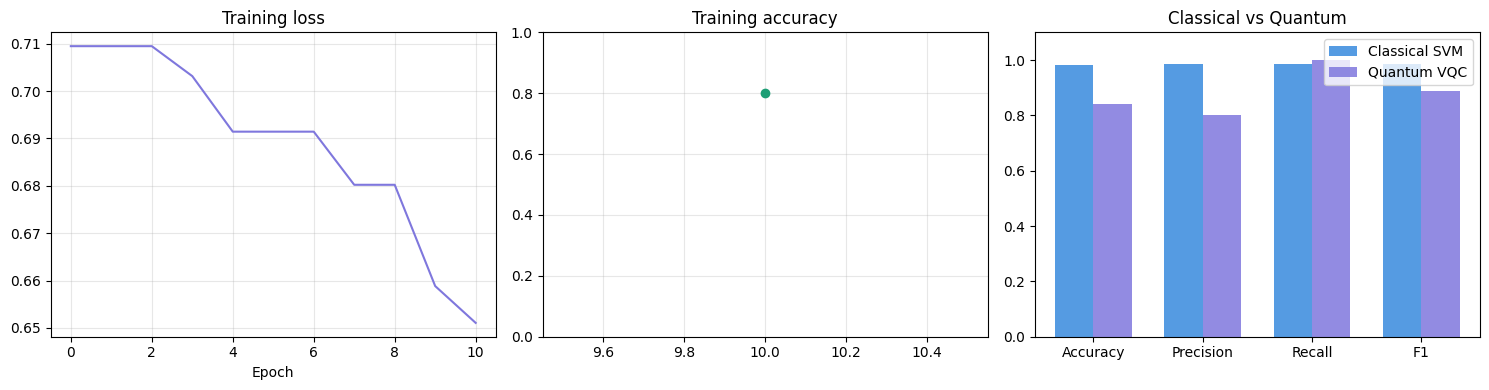

Plot saved as quantum_results.png


In [0]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(loss_history, color='#7F77DD', linewidth=1.5)
axes[0].set_title('Training loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(True, alpha=0.3)
epochs_x = [10*(i+1) for i in range(len(acc_history))]
axes[1].plot(epochs_x, acc_history, 'o-', color='#1D9E75', linewidth=1.5)
axes[1].set_title('Training accuracy'); axes[1].set_ylim([0, 1]); axes[1].grid(True, alpha=0.3)
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1']
classical_vals = [classical_metrics[m.lower()] for m in metrics_list]
quantum_vals   = [quantum_metrics[m.lower()] for m in metrics_list]
x = np.arange(len(metrics_list)); width = 0.35
axes[2].bar(x - width/2, classical_vals, width, label='Classical SVM', color='#378ADD', alpha=0.85)
axes[2].bar(x + width/2, quantum_vals,   width, label='Quantum VQC',   color='#7F77DD', alpha=0.85)
axes[2].set_title('Classical vs Quantum'); axes[2].set_xticks(x)
axes[2].set_xticklabels(metrics_list); axes[2].set_ylim([0, 1.1]); axes[2].legend()
plt.tight_layout()
plt.savefig('quantum_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as quantum_results.png')

In [0]:
s3 = boto3.client('s3', region_name=REGION)
all_results = {
    'timestamp': datetime.now().isoformat(),
    'experiment': 'Hybrid Quantum-Classical Breast Cancer Classifier',
    'quantum_backend': 'AWS Braket Local Simulator',
    'config': {'n_qubits': N_QUBITS, 'n_layers': N_LAYERS, 'n_epochs': N_EPOCHS},
    'classical_svm': classical_metrics,
    'quantum_vqc': quantum_metrics,
    'loss_history': loss_history
}
s3.put_object(Bucket=S3_BUCKET, Key='results/experiment_results.json',
    Body=json.dumps(all_results, indent=2))
print('Results JSON saved to S3')
with open('quantum_results.png', 'rb') as f:
    s3.put_object(Bucket=S3_BUCKET, Key='results/quantum_results.png',
        Body=f.read(), ContentType='image/png')
print('Plot saved to S3')
np.save('quantum_weights.npy', np.array(weights))
with open('quantum_weights.npy', 'rb') as f:
    s3.put_object(Bucket=S3_BUCKET, Key='models/quantum_weights.npy', Body=f.read())
print(f'All outputs saved to s3://{S3_BUCKET}/')

Results JSON saved to S3
Plot saved to S3
All outputs saved to s3://YOUR-BUCKET-NAME/


In [0]:
cloudwatch = boto3.client('cloudwatch', region_name=REGION)
metrics_to_push = [
    ('QuantumAccuracy',   quantum_metrics['accuracy']),
    ('ClassicalAccuracy', classical_metrics['accuracy']),
    ('QuantumF1',         quantum_metrics['f1']),
    ('ClassicalF1',       classical_metrics['f1']),
    ('TrainingTimeSec',   quantum_metrics['train_time_seconds']),
]
cloudwatch.put_metric_data(
    Namespace='QuantumClassifier/Experiment',
    MetricData=[{'MetricName': name, 'Value': value, 'Unit': 'None',
        'Dimensions': [{'Name': 'ExperimentID', 'Value': 'v1-breast-cancer'}]}
        for name, value in metrics_to_push])
print('Metrics pushed to CloudWatch: QuantumClassifier/Experiment')
print('Go to CloudWatch -> Metrics -> Custom Namespaces to see graphs')

Metrics pushed to CloudWatch: QuantumClassifier/Experiment
Go to CloudWatch -> Metrics -> Custom Namespaces to see graphs


## Shutdown cells

In [0]:
"""
Stop spark session and associated Athena Spark session
"""

from IPython import get_ipython as _get_ipython
_get_ipython().user_ns["spark"].stop()